<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/02_modelisation/blob/main/VGG16_without_Data_augmentation_and_without_CLAHE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 0 - Import required libraries and set reproducibility

from pathlib import Path
import kagglehub

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

# ---------------------------------------
# Set random seeds for reproducibility
# ---------------------------------------

SEED = 42

tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

np.random.seed(SEED)
random.seed(SEED)

# ---------------------------------------
# Display available GPUs
# ---------------------------------------

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 1 - Download Kaggle dataset and define paths

path = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)

# Convert dataset path to Path object
base_path = Path(path)

# Main dataset folder
data_path = base_path / "COVID-19_Radiography_Dataset"

print("Dataset downloaded to:", base_path)
print("Main dataset folder:", data_path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset downloaded to: /kaggle/input/covid19-radiography-database
Main dataset folder: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [3]:
# Cell 2 - Inspect dataset structure

class_folders = sorted(
    [
        item.name
        for item in data_path.iterdir()
        if item.is_dir()
    ]
)

print("Class folders found in the dataset:")
print(class_folders)

Class folders found in the dataset:
['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


In [4]:
# Cell 3 - # Optional sanity check before building the final dataframe (Check dataset summary table and image/mask filename matching)

mismatch_report = []
# Create an empty list to store matching results for each class

for class_name in class_folders:
    # Loop through each class folder

    class_path = data_path / class_name
    # Build the full path of the current class

    images_path = class_path / "images"
    # Path to the images folder

    masks_path = class_path / "masks"
    # Path to the masks folder

    image_files = sorted([item.name for item in images_path.iterdir() if item.is_file()])
    # Get a sorted list of image filenames

    mask_files = sorted([item.name for item in masks_path.iterdir() if item.is_file()])
    # Get a sorted list of mask filenames

    filenames_match = image_files == mask_files
    # Check whether image and mask filenames match exactly

    mismatch_report.append({
        "class_name": class_name,
        "num_image_files": len(image_files),
        "num_mask_files": len(mask_files),
        "filenames_match": filenames_match
    })
    # Store the matching information for the current class

mismatch_df = pd.DataFrame(mismatch_report)
# Convert the matching report into a pandas DataFrame

mismatch_df
# Display the matching results

,class_name,num_image_files,num_mask_files,filenames_match
0,COVID,3616,3616,True
1,Lung_Opacity,6012,6012,True
2,Normal,10192,10192,True
3,Viral Pneumonia,1345,1345,True


In [5]:
# Cell 4 - Load predefined train / validation / test splits from GitHub

train_url = "https://raw.githubusercontent.com/mar25-iia2-radiographies/01_data_exploration/main/dataset_splits/train_df.csv"

val_url = "https://raw.githubusercontent.com/mar25-iia2-radiographies/01_data_exploration/main/dataset_splits/val_df.csv"

test_url = "https://raw.githubusercontent.com/mar25-iia2-radiographies/01_data_exploration/main/dataset_splits/test_df.csv"

# Load CSV files into pandas dataframes
train_df = pd.read_csv(train_url)

val_df = pd.read_csv(val_url)

test_df = pd.read_csv(test_url)

# Display dataset sizes
print("Training set size:", train_df.shape)

print("Validation set size:", val_df.shape)

print("Test set size:", test_df.shape)

# Display first rows
print("\nTraining dataframe:")
display(train_df.head())

print("\nValidation dataframe:")
display(val_df.head())

print("\nTest dataframe:")
display(test_df.head())

Training set size: (14815, 3)
Validation set size: (3175, 3)
Test set size: (3175, 3)

Training dataframe:


,label,image_path,mask_path
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...



Validation dataframe:


,label,image_path,mask_path
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...



Test dataframe:


,label,image_path,mask_path
0,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


In [6]:
# Cell 5 - Check class distribution in train / validation / test sets

# -------------------------------
# Training distribution
# -------------------------------

print("Training class distribution:")
print(train_df["label"].value_counts(normalize=True) * 100)

# -------------------------------
# Validation distribution
# -------------------------------

print("\nValidation class distribution:")
print(val_df["label"].value_counts(normalize=True) * 100)

# -------------------------------
# Test distribution
# -------------------------------

print("\nTest class distribution:")
print(test_df["label"].value_counts(normalize=True) * 100)

Training class distribution:
label
Normal             48.153898
Lung_Opacity       28.403645
COVID              17.084036
Viral Pneumonia     6.358421
Name: proportion, dtype: float64

Validation class distribution:
label
Normal             48.157480
Lung_Opacity       28.409449
COVID              17.102362
Viral Pneumonia     6.330709
Name: proportion, dtype: float64

Test class distribution:
label
Normal             48.157480
Lung_Opacity       28.409449
COVID              17.070866
Viral Pneumonia     6.362205
Name: proportion, dtype: float64


In [7]:
# Cell 6 - Preprocess images and save them into train / val / test folders

IMG_SIZE = (224, 224)
# Define the image size required by VGG16

BATCH_SIZE = 32
# Define the batch size used during training

processed_base_path = Path("processed_dataset")
# Define the main output folder for processed images

for split_name, dataframe in zip(
    ["train", "val", "test"],
    [train_df, val_df, test_df]
):
    # Loop through each dataset split

    for _, row in dataframe.iterrows():
        # Loop through each row of the dataframe

        label = row["label"]
        # Get the class label

        image_path = row["image_path"]
        # Get the image path

        mask_path = row["mask_path"]
        # Get the mask path

        # Read the X-ray image in grayscale
        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Read the corresponding lung mask
        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Resize the mask to match image dimensions
        mask_resized = cv2.resize(
            mask,
            (image.shape[1], image.shape[0])
        )

        # Convert resized mask back to binary
        _, mask_binary = cv2.threshold(
            mask_resized,
            127,
            255,
            cv2.THRESH_BINARY
        )

        # Apply the mask to keep only the lung region
        masked_image = cv2.bitwise_and(
            image,
            image,
            mask=mask_binary
        )

        # Resize image to VGG16 input size
        resized_image = cv2.resize(
            masked_image,
            IMG_SIZE
        )

        # Create output folder:
        # processed_dataset/train/COVID/
        output_folder = (
            processed_base_path /
            split_name /
            label
        )

        output_folder.mkdir(
            parents=True,
            exist_ok=True
        )
        # Create folders if they do not exist

        # Get the image filename only
        output_filename = Path(image_path).name

        # Final output path
        output_path = output_folder / output_filename

        # Save the processed image
        cv2.imwrite(
            str(output_path),
            resized_image
        )

print("Processed dataset created successfully.")
print("Processed images saved in:", processed_base_path)

# ---------------------------------------------------
# Display processed dataset folder structure
# ---------------------------------------------------

print("\nProcessed dataset structure:\n")

for split_folder in processed_base_path.iterdir():

    if split_folder.is_dir():

        print(f"{split_folder.name}/")

        for class_folder in sorted(split_folder.iterdir()):

            if class_folder.is_dir():

                print(f"    {class_folder.name}/")

Processed dataset created successfully.
Processed images saved in: processed_dataset

Processed dataset structure:

train/
    COVID/
    Lung_Opacity/
    Normal/
    Viral Pneumonia/
val/
    COVID/
    Lung_Opacity/
    Normal/
    Viral Pneumonia/
test/
    COVID/
    Lung_Opacity/
    Normal/
    Viral Pneumonia/


In [8]:
# Cell 7 - Load train, validation and test datasets

train_dataset = tf.keras.utils.image_dataset_from_directory(

    "processed_dataset/train",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=True,

    seed=SEED

)

val_dataset = tf.keras.utils.image_dataset_from_directory(

    "processed_dataset/val",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=False

)

test_dataset = tf.keras.utils.image_dataset_from_directory(

    "processed_dataset/test",

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=False

)

print("Datasets loaded successfully.")

Found 14815 files belonging to 4 classes.
Found 3175 files belonging to 4 classes.
Found 3175 files belonging to 4 classes.
Datasets loaded successfully.


In [9]:
# Cell 8 - Build the VGG16 transfer learning model

# Define model input
inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

# No data augmentation
x = inputs

# Load pretrained VGG16
base_model = tf.keras.applications.VGG16(

    weights="imagenet",
    # Load pretrained ImageNet weights

    include_top=False,
    # Remove original VGG16 classifier

    input_tensor=x

)

# Freeze pretrained convolutional layers
base_model.trainable = False

# Extract feature maps from VGG16
x = base_model.output

# Convert feature maps into a feature vector
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# First dense layer
x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

# Second dense layer
x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

# Final classification layer
outputs = tf.keras.layers.Dense(
    4,
    activation="softmax"
)(x)

# Create final model
model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

print("VGG16 model created successfully.")

base_model.summary()

VGG16 model created successfully.


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
# Cell 9 - Compile the VGG16 model

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    # Define optimizer

    loss="categorical_crossentropy",
    # Loss function for multiclass classification

    metrics=[

        tf.keras.metrics.CategoricalAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )

    ]

)

print("Model compiled successfully.")

Model compiled successfully.


In [11]:
# Cell 10 - Define training callbacks

early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",
    # Monitor validation loss

    patience=5,
    # Stop training if val_loss does not improve for 5 epochs

    restore_best_weights=True
    # Restore the best model weights

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",
    # Monitor validation loss

    factor=0.5,
    # Reduce learning rate by half

    patience=2,
    # Wait 2 epochs before reducing learning rate

    min_lr=1e-6
    # Minimum learning rate

)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "best_classifier.keras",
    # File name for saving the best model

    monitor="val_loss",
    # Monitor validation loss

    save_best_only=True
    # Save only the best model

)

print("Callbacks created successfully.")

Callbacks created successfully.


In [12]:
# Cell 11 - Compute class weights

# Get training labels
train_labels = train_df["label"]

# Get unique class names
class_names = np.array(
    sorted(train_labels.unique())
)

# Compute balanced class weights
class_weights = compute_class_weight(

    class_weight="balanced",

    classes=class_names,

    y=train_labels

)

# Convert to dictionary format
class_weight_dict = {

    i: weight
    for i, weight in enumerate(class_weights)

}

print("Class weights:")
print(class_weight_dict)

Class weights:
{0: np.float64(1.4633544053733702), 1: np.float64(0.8801687262357415), 2: np.float64(0.5191687692738997), 3: np.float64(3.9317940552016983)}


In [13]:
# Cell 12 - Train the VGG16 model

history = model.fit(

    train_dataset,
    # Training dataset

    validation_data=val_dataset,
    # Validation dataset

    epochs=30,
    # Maximum number of epochs

    class_weight=class_weight_dict,
    # Apply class weights to handle class imbalance

    callbacks=[

        early_stopping,
        reduce_lr,
        model_checkpoint

    ],
    # Training callbacks

    verbose=1
    # Display training progress

)

print("Training completed successfully.")

Epoch 1/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 76s 154ms/step - accuracy: 0.4603 - loss: 1.3124 - precision: 0.5028 - recall: 0.3423 - val_accuracy: 0.6746 - val_loss: 0.8550 - val_precision: 0.7719 - val_recall: 0.4583 - learning_rate: 1.0000e-04
Epoch 2/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 82s 177ms/step - accuracy: 0.6112 - loss: 0.8568 - precision: 0.6786 - recall: 0.4855 - val_accuracy: 0.7216 - val_loss: 0.7121 - val_precision: 0.7870 - val_recall: 0.6214 - learning_rate: 1.0000e-04
Epoch 3/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 88s 189ms/step - accuracy: 0.6583 - loss: 0.7516 - precision: 0.7198 - recall: 0.5633 - val_accuracy: 0.7335 - val_loss: 0.6732 - val_precision: 0.7959 - val_recall: 0.6535 - learning_rate: 1.0000e-04
Epoch 4/30
463/463 ━━━━━━━━━━━━━━━━━━━━ 82s 177ms/step - accuracy: 0.6812 - loss: 0.6909 - precision: 0.7400 - recall: 0.5997 - val_accuracy: 0.7569 - val_loss: 0.6292 - val_precision: 0.8016 - val_recall: 0.6935 - learning_rate: 1.0000e-04
Epoch 5/30
463/463 ━━━━━━━━━━━━━━━━━

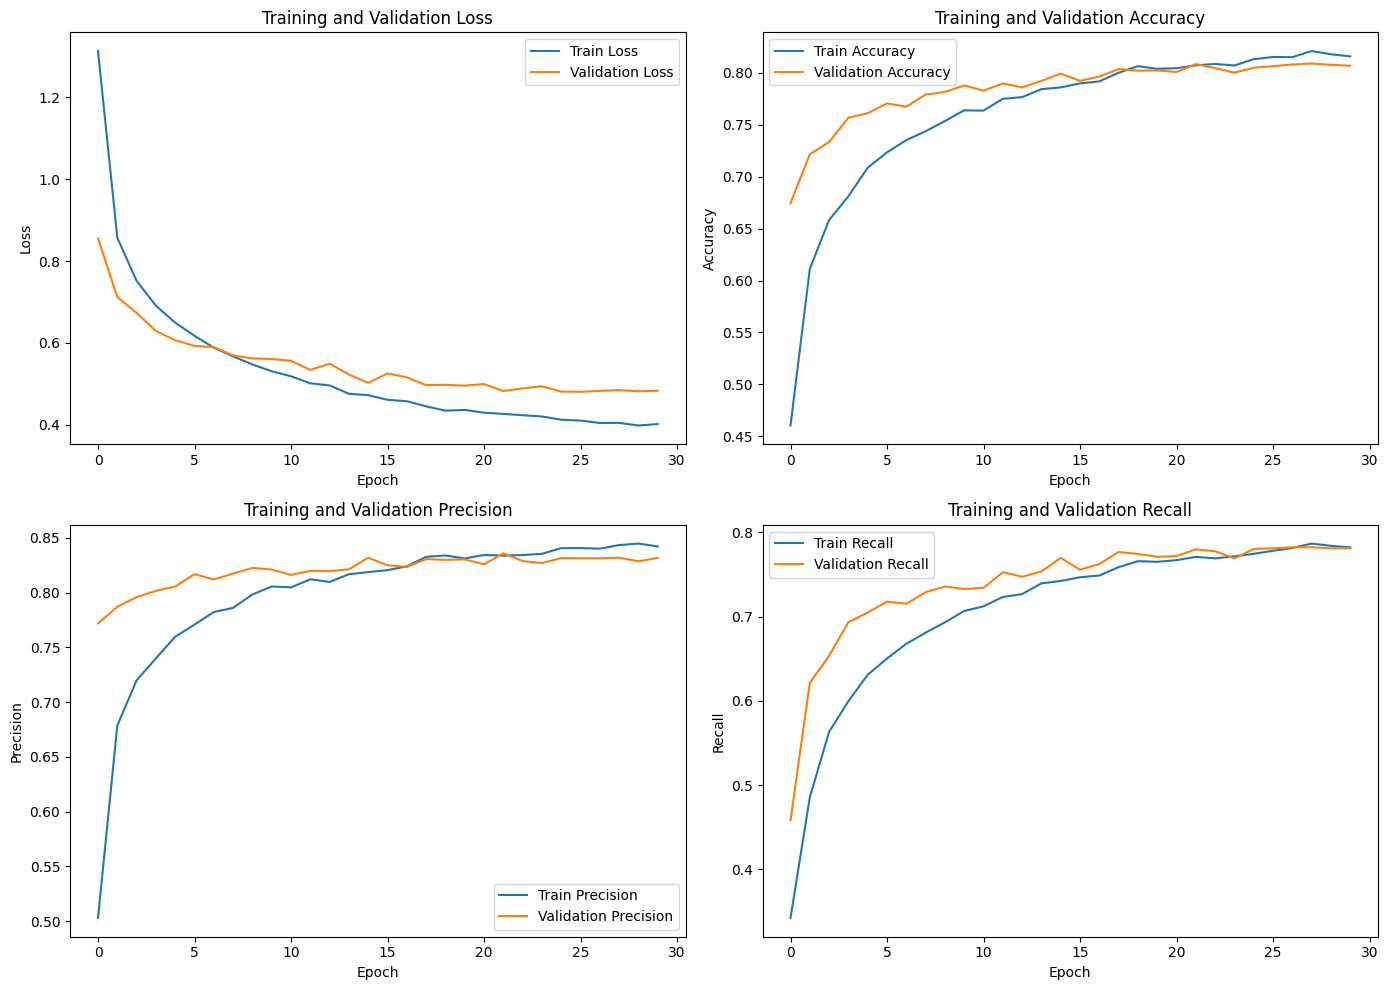

In [14]:
# Cell 13 - Plot training curves

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# ---------------------------------------------------
# Loss
# ---------------------------------------------------

axes[0, 0].plot(
    history.history["loss"],
    label="Train Loss"
)

axes[0, 0].plot(
    history.history["val_loss"],
    label="Validation Loss"
)

axes[0, 0].set_title(
    "Training and Validation Loss"
)

axes[0, 0].set_xlabel("Epoch")

axes[0, 0].set_ylabel("Loss")

axes[0, 0].legend()

# ---------------------------------------------------
# Accuracy
# ---------------------------------------------------

axes[0, 1].plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

axes[0, 1].plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

axes[0, 1].set_title(
    "Training and Validation Accuracy"
)

axes[0, 1].set_xlabel("Epoch")

axes[0, 1].set_ylabel("Accuracy")

axes[0, 1].legend()

# ---------------------------------------------------
# Precision
# ---------------------------------------------------

axes[1, 0].plot(
    history.history["precision"],
    label="Train Precision"
)

axes[1, 0].plot(
    history.history["val_precision"],
    label="Validation Precision"
)

axes[1, 0].set_title(
    "Training and Validation Precision"
)

axes[1, 0].set_xlabel("Epoch")

axes[1, 0].set_ylabel("Precision")

axes[1, 0].legend()

# ---------------------------------------------------
# Recall
# ---------------------------------------------------

axes[1, 1].plot(
    history.history["recall"],
    label="Train Recall"
)

axes[1, 1].plot(
    history.history["val_recall"],
    label="Validation Recall"
)

axes[1, 1].set_title(
    "Training and Validation Recall"
)

axes[1, 1].set_xlabel("Epoch")

axes[1, 1].set_ylabel("Recall")

axes[1, 1].legend()

# Adjust spacing
plt.tight_layout()

# Display all plots
plt.show()

## Analyse des courbes d’apprentissage du modèle VGG16

### 1. Configuration du modèle

Dans cette expérience, le modèle **VGG16 pré-entraîné sur ImageNet** a été utilisé en mode **feature extraction**, c’est-à-dire que les couches convolutionnelles du modèle sont restées gelées et seule la partie **classifier** a été entraînée.

De plus, cette version du modèle a été exécutée **sans data augmentation** afin de permettre une comparaison plus équitable avec les autres architectures du projet.

---

### 2. Analyse des courbes de loss

Les courbes montrent que la train loss diminue progressivement au cours des epochs, ce qui indique que le modèle apprend correctement les caractéristiques des données d’entraînement.

La validation loss diminue également au début de l’entraînement puis tend progressivement à se stabiliser à partir des epochs intermédiaires.

L’écart entre la train loss et la validation loss reste relativement limité, ce qui signifie qu’il n’y a pas de surapprentissage important (overfitting sévère).

Cependant, vers les derniers epochs, la train loss continue légèrement à diminuer alors que la validation loss n’apporte plus d’amélioration significative. Cela peut indiquer le début d’un léger overfitting, mais celui-ci reste modéré.

---

### 3. Analyse des métriques Accuracy, Precision et Recall

Les courbes d’**accuracy**, de **precision** et de **recall** montrent une progression stable aussi bien sur les données d’entraînement que sur les données de validation.

Les métriques de validation restent proches des métriques d’entraînement pendant la majorité des epochs, ce qui indique une capacité de généralisation relativement correcte du modèle.

Les valeurs finales obtenues suggèrent que le modèle a réussi à apprendre des représentations pertinentes des radiographies thoraciques malgré l’absence de data augmentation.

---

### 4. Concernant l’EarlyStopping

L’algorithme EarlyStopping ne s’est pas activé pendant l’entraînement puisque les 30 epochs ont été exécutés jusqu’à la fin.

Cela signifie que la validation loss a continué à présenter soit de petites améliorations, soit des variations insuffisantes pour déclencher la condition d’arrêt définie avec :

- `monitor = "val_loss"`
- `patience = 5`

Ainsi, même si un léger overfitting apparaît vers la fin de l’apprentissage, celui-ci n’a pas été suffisamment important ou prolongé pour activer l’arrêt anticipé.

---

### 5. Conclusion

Globalement, les courbes montrent un comportement d’apprentissage relativement stable.

Le modèle ne présente :
- **ni underfitting**
- **ni overfitting**

On observe uniquement un **léger début de surapprentissage** dans les derniers epochs.

Ces résultats montrent que le modèle VGG16 en mode feature extraction, sans data augmentation, parvient à obtenir une performance relativement équilibrée sur cette tâche de classification de radiographies pulmonaires.

100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.8255 - loss: 0.4550 - precision: 0.8515 - recall: 0.7962
Test Loss: 0.4549887776374817
Test Accuracy: 0.8255118131637573
Test Precision: 0.8514651656150818
Test Recall: 0.7962204813957214
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step

Classification Report:

                 precision    recall  f1-score   support

          COVID       0.63      0.77      0.69       542
   Lung_Opacity       0.84      0.78      0.81       902
         Normal       0.90      0.86      0.88      1529
Viral Pneumonia       0.87      0.93      0.90       202

       accuracy                           0.83      3175
      macro avg       0.81      0.83      0.82      3175
   weighted avg       0.83      0.83      0.83      3175


Macro F1-score: 0.8199523422348276


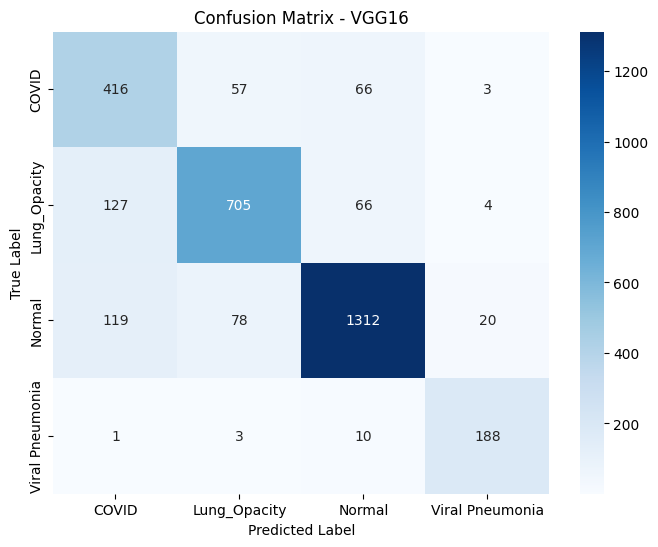

In [15]:
# Cell 14 - Evaluate best saved VGG16 model on test set

# ---------------------------------------------------
# Load best saved model
# ---------------------------------------------------

best_model = tf.keras.models.load_model(
    "best_classifier.keras"
)

print("Best saved model loaded successfully.")

# ---------------------------------------------------
# Evaluate model on test dataset
# ---------------------------------------------------

test_loss, test_accuracy, test_precision, test_recall = best_model.evaluate(

    test_dataset,

    verbose=1

)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

print("Test Precision:", test_precision)

print("Test Recall:", test_recall)

# ---------------------------------------------------
# Predict probabilities
# ---------------------------------------------------

y_pred_probs = best_model.predict(
    test_dataset
)

# Convert probabilities to predicted classes
y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

# ---------------------------------------------------
# Get true labels
# ---------------------------------------------------

y_true = np.concatenate([

    y for x, y in test_dataset

], axis=0)

y_true = np.argmax(
    y_true,
    axis=1
)

# ---------------------------------------------------
# Classification report
# ---------------------------------------------------

print("\nClassification Report:\n")

print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )

)

# ---------------------------------------------------
# Compute Macro F1-score
# ---------------------------------------------------

macro_f1 = f1_score(

    y_true,

    y_pred,

    average="macro"

)

print("\nMacro F1-score:", macro_f1)

# ---------------------------------------------------
# Confusion matrix
# ---------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix - VGG16")

plt.show()

## Analyse des performances du modèle VGG16

### 1. Performance globale

Le modèle VGG16 atteint une accuracy d’environ **83 %** sur l’ensemble de test, avec un **Macro F1-score proche de 0.82**.

Le fait que l’accuracy et le Macro F1-score soient relativement proches montre que le modèle ne se contente pas d’obtenir de bonnes performances uniquement sur les classes majoritaires, mais conserve également un comportement relativement équilibré sur les classes minoritaires.

Cela suggère que l’utilisation des class weights a contribué à limiter l’impact du déséquilibre des classes.

---

### 2. Analyse par classe

#### COVID

La classe COVID présente les performances les plus faibles avec un F1-score d’environ **0.69**.

Le recall reste relativement correct, ce qui signifie que le modèle parvient à détecter une partie importante des cas COVID. Cependant, la precision est plus faible, indiquant que certaines images appartenant à d’autres classes sont incorrectement prédites comme COVID.

---

#### Lung_Opacity

La classe Lung_Opacity obtient des performances globalement satisfaisantes, mais présente une confusion importante avec la classe COVID.

Cette confusion est visible dans la matrice de confusion et peut s’expliquer par des similarités radiologiques entre certaines opacités pulmonaires et les manifestations du COVID-19.

---

#### Normal

La classe Normal présente les meilleures performances globales avec un F1-score élevé.

Cela peut être lié à la présence d’un plus grand nombre d’échantillons ainsi qu’à des caractéristiques visuelles plus distinctes.

---

#### Viral Pneumonia

Malgré un nombre plus faible d’échantillons, la classe Viral Pneumonia obtient de très bonnes performances.

Cela montre que le modèle parvient relativement bien à identifier cette catégorie et que les class weights ont probablement aidé à améliorer la prise en compte des classes minoritaires.

---

### 3. Analyse de la matrice de confusion

La majorité des prédictions correctes se situent sur la diagonale principale de la matrice de confusion, ce qui indique un comportement globalement cohérent du modèle.

Les erreurs principales concernent surtout la confusion entre :
- COVID et Lung_Opacity
- certaines images Normal prédites comme COVID

Ces résultats restent cohérents avec la difficulté clinique de différencier certaines anomalies pulmonaires sur les radiographies thoraciques.

---

### 4. Conclusion

Globalement, le modèle VGG16 sans data augmentation montre une capacité de généralisation relativement stable.

Le modèle ne présente pas de signe important de surapprentissage et atteint des performances équilibrées sur plusieurs classes.

Cependant, des difficultés persistent pour distinguer certaines classes présentant des caractéristiques radiologiques proches, notamment COVID et Lung_Opacity.

## Transition vers la phase de fine-tuning

Il est important de noter que les résultats précédents ont été obtenus uniquement avec la phase de **feature extraction / classifier-only training**.

Dans cette configuration :
- les couches convolutionnelles pré-entraînées de **VGG16** sont restées gelées ;
- seule la partie **classifier** ajoutée au-dessus du modèle pré-entraîné a été entraînée.

Cette première étape permet d’évaluer les performances de base du modèle sans modifier les poids internes appris sur ImageNet.

---

## Étape suivante : Fine-tuning du modèle

Après cette première phase d’évaluation, l’étape suivante consiste à effectuer un **fine-tuning partiel** du modèle VGG16.

Pour cela, le **Block 5** du réseau sera dégelé (*unfrozen*) afin d’autoriser la mise à jour des poids des dernières couches convolutionnelles pendant l’entraînement.

L’objectif de cette étape est de permettre au modèle :
- d’adapter plus finement les caractéristiques extraites aux radiographies pulmonaires ;
- d’améliorer potentiellement la séparation entre certaines classes proches, notamment :
  - COVID
  - Lung_Opacity

Le fine-tuning sera réalisé avec un **learning rate plus faible** afin de préserver les connaissances pré-entraînées du modèle tout en ajustant progressivement les représentations aux données médicales du projet.

In [16]:
# Cell 15 - Configure Block 5 fine-tuning

# Freeze all VGG16 layers
base_model.trainable = False

# Unfreeze only Block 5
for layer in base_model.layers:

    if layer.name.startswith("block5"):

        layer.trainable = True

# Display trainable layers
for layer in base_model.layers:

    print(
        layer.name,
        "- Trainable:", layer.trainable
    )

# Recompile the model with a smaller learning rate
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="categorical_crossentropy",

    metrics=[

        tf.keras.metrics.CategoricalAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        )

    ]

)

print("Block 5 fine-tuning configuration completed.")

input_layer - Trainable: False
block1_conv1 - Trainable: False
block1_conv2 - Trainable: False
block1_pool - Trainable: False
block2_conv1 - Trainable: False
block2_conv2 - Trainable: False
block2_pool - Trainable: False
block3_conv1 - Trainable: False
block3_conv2 - Trainable: False
block3_conv3 - Trainable: False
block3_pool - Trainable: False
block4_conv1 - Trainable: False
block4_conv2 - Trainable: False
block4_conv3 - Trainable: False
block4_pool - Trainable: False
block5_conv1 - Trainable: True
block5_conv2 - Trainable: True
block5_conv3 - Trainable: True
block5_pool - Trainable: True
Block 5 fine-tuning configuration completed.


In [17]:
# Cell 16 - Fine-tune Block 5 of VGG16

# ---------------------------------------------------
# Early stopping for Block 5 fine-tuning
# ---------------------------------------------------

block5_early_stopping = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

# ---------------------------------------------------
# Reduce learning rate for Block 5 fine-tuning
# ---------------------------------------------------

block5_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-6

)

# ---------------------------------------------------
# Checkpoint for Block 5 fine-tuning
# ---------------------------------------------------

block5_checkpoint = tf.keras.callbacks.ModelCheckpoint(

    "best_block5.keras",

    monitor="val_loss",

    save_best_only=True

)

# ---------------------------------------------------
# Train Block 5 fine-tuning
# ---------------------------------------------------

block5_history = model.fit(

    train_dataset,
    # Training dataset

    validation_data=val_dataset,
    # Validation dataset

    epochs=20,
    # Fine-tuning epochs

    class_weight=class_weight_dict,
    # Handle class imbalance

    callbacks=[

        block5_early_stopping,
        block5_reduce_lr,
        block5_checkpoint

    ],
    # Training callbacks

    verbose=1
    # Display training progress

)

print("Block 5 fine-tuning completed successfully.")

Epoch 1/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 93s 197ms/step - accuracy: 0.8014 - loss: 0.4355 - precision: 0.8299 - recall: 0.7685 - val_accuracy: 0.8110 - val_loss: 0.5006 - val_precision: 0.8294 - val_recall: 0.7808 - learning_rate: 1.0000e-05
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 93s 200ms/step - accuracy: 0.8301 - loss: 0.3697 - precision: 0.8530 - recall: 0.8021 - val_accuracy: 0.8457 - val_loss: 0.4008 - val_precision: 0.8649 - val_recall: 0.8306 - learning_rate: 1.0000e-05
Epoch 3/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 93s 200ms/step - accuracy: 0.8538 - loss: 0.3253 - precision: 0.8713 - recall: 0.8302 - val_accuracy: 0.8482 - val_loss: 0.4155 - val_precision: 0.8600 - val_recall: 0.8265 - learning_rate: 1.0000e-05
Epoch 4/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 94s 202ms/step - accuracy: 0.8655 - loss: 0.2968 - precision: 0.8827 - recall: 0.8458 - val_accuracy: 0.8501 - val_loss: 0.3893 - val_precision: 0.8643 - val_recall: 0.8328 - learning_rate: 1.0000e-05
Epoch 5/20
463/463 ━━━━━━━━━━━━━━━━━

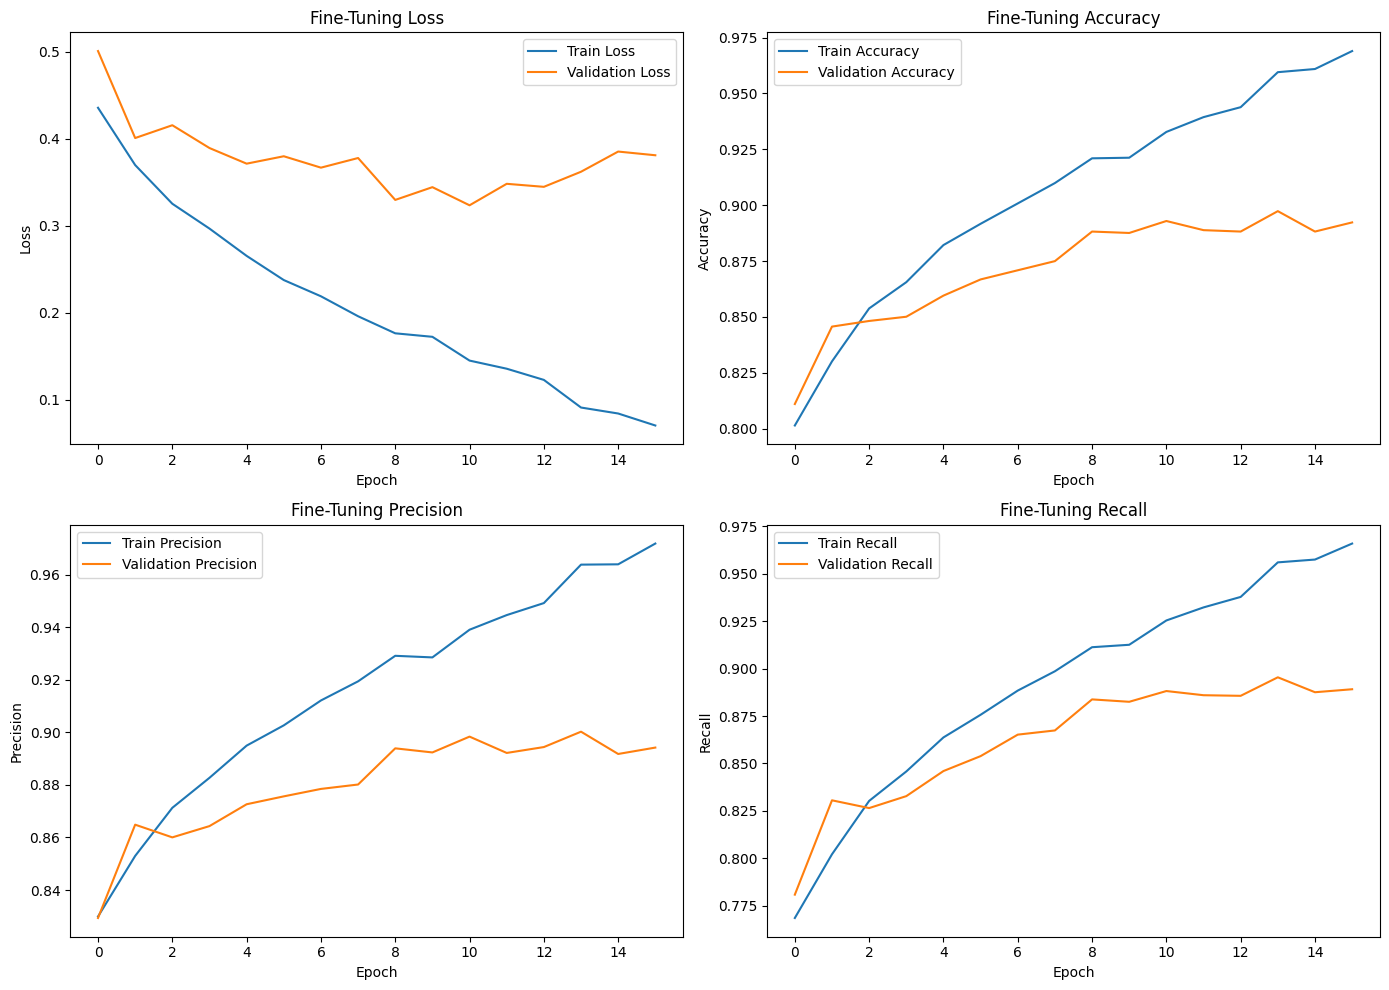

In [18]:
# Cell 17 - Plot fine-tuning (block 5) curves

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# ---------------------------------------------------
# Loss
# ---------------------------------------------------

axes[0, 0].plot(

    block5_history.history["loss"],

    label="Train Loss"

)

axes[0, 0].plot(

    block5_history.history["val_loss"],

    label="Validation Loss"

)

axes[0, 0].set_title(
    "Fine-Tuning Loss"
)

axes[0, 0].set_xlabel("Epoch")

axes[0, 0].set_ylabel("Loss")

axes[0, 0].legend()

# ---------------------------------------------------
# Accuracy
# ---------------------------------------------------

axes[0, 1].plot(

    block5_history.history["accuracy"],

    label="Train Accuracy"

)

axes[0, 1].plot(

    block5_history.history["val_accuracy"],

    label="Validation Accuracy"

)

axes[0, 1].set_title(
    "Fine-Tuning Accuracy"
)

axes[0, 1].set_xlabel("Epoch")

axes[0, 1].set_ylabel("Accuracy")

axes[0, 1].legend()

# ---------------------------------------------------
# Precision
# ---------------------------------------------------

axes[1, 0].plot(

    block5_history.history["precision"],

    label="Train Precision"

)

axes[1, 0].plot(

    block5_history.history["val_precision"],

    label="Validation Precision"

)

axes[1, 0].set_title(
    "Fine-Tuning Precision"
)

axes[1, 0].set_xlabel("Epoch")

axes[1, 0].set_ylabel("Precision")

axes[1, 0].legend()

# ---------------------------------------------------
# Recall
# ---------------------------------------------------

axes[1, 1].plot(

    block5_history.history["recall"],

    label="Train Recall"

)

axes[1, 1].plot(

    block5_history.history["val_recall"],

    label="Validation Recall"

)

axes[1, 1].set_title(
    "Fine-Tuning Recall"
)

axes[1, 1].set_xlabel("Epoch")

axes[1, 1].set_ylabel("Recall")

axes[1, 1].legend()

# ---------------------------------------------------
# Adjust layout
# ---------------------------------------------------

plt.tight_layout()

plt.show()

## Analyse des courbes de fine-tuning

Les courbes de fine-tuning montrent qu’après le dégel du Block 5, le modèle améliore fortement ses performances sur les données d’entraînement. Les métriques d’Accuracy, de Precision et de Recall augmentent progressivement tandis que la Loss d’entraînement diminue continuellement.

Cependant, les performances sur les données de validation progressent plus lentement. À partir d’environ les epochs 8 à 10, l’écart entre les courbes d’entraînement et de validation devient plus important.

De plus, la Validation Loss recommence légèrement à augmenter après une première phase de diminution, ce qui indique un début de surapprentissage (overfitting).

Malgré cela, les métriques de validation restent relativement élevées, ce qui suggère que le modèle conserve encore une bonne capacité de généralisation sur les données non vues.

Même si l’entraînement a continué jusqu’à l’epoch 16, le callback ModelCheckpoint a sauvegardé automatiquement les meilleurs poids du modèle selon la plus faible valeur de validation loss.

Ainsi, l’évaluation finale a été réalisée sur la meilleure version sauvegardée du modèle et non sur les poids du dernier epoch d’entraînement.

Best Block5 fine-tuned model loaded successfully.
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.8882 - loss: 0.3202 - precision: 0.8922 - recall: 0.8841

===== TEST RESULTS =====
Test Loss      : 0.3202
Test Accuracy  : 0.8882
Test Precision : 0.8922
Test Recall    : 0.8841
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step

===== CLASSIFICATION REPORT =====

                 precision    recall  f1-score   support

          COVID       0.81      0.86      0.83       542
   Lung_Opacity       0.89      0.85      0.87       902
         Normal       0.91      0.92      0.91      1529
Viral Pneumonia       0.96      0.93      0.94       202

       accuracy                           0.89      3175
      macro avg       0.89      0.89      0.89      3175
   weighted avg       0.89      0.89      0.89      3175


Macro F1-score: 0.8892487071427615


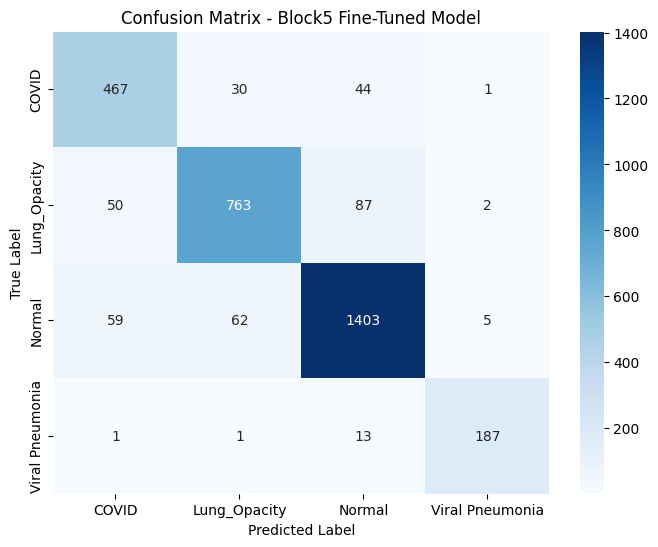

In [20]:
# Cell 18 - Evaluate the best saved Block5 fine-tuned model

# ---------------------------------------------------
# Load best saved Block5 model
# ---------------------------------------------------

best_model = tf.keras.models.load_model(
    "best_block5.keras"
)

print("Best Block5 fine-tuned model loaded successfully.")

# ---------------------------------------------------
# Evaluate on test dataset
# ---------------------------------------------------

test_results = best_model.evaluate(

    test_dataset,

    verbose=1

)

print("\n===== TEST RESULTS =====")

print(f"Test Loss      : {test_results[0]:.4f}")

print(f"Test Accuracy  : {test_results[1]:.4f}")

print(f"Test Precision : {test_results[2]:.4f}")

print(f"Test Recall    : {test_results[3]:.4f}")

# ---------------------------------------------------
# Predict probabilities
# ---------------------------------------------------

y_pred_probs = best_model.predict(

    test_dataset

)

# Convert probabilities to predicted classes
y_pred = np.argmax(

    y_pred_probs,
    axis=1

)

# ---------------------------------------------------
# Get true labels
# ---------------------------------------------------

y_true = np.concatenate([

    np.argmax(y.numpy(), axis=1)

    for x, y in test_dataset

])

# ---------------------------------------------------
# Classification report
# ---------------------------------------------------

print("\n===== CLASSIFICATION REPORT =====\n")

print(

    classification_report(

        y_true,
        y_pred,

        target_names=class_names

    )

)

# ---------------------------------------------------
# Compute Macro F1-score
# ---------------------------------------------------

macro_f1 = f1_score(

    y_true,
    y_pred,

    average="macro"

)

print("\nMacro F1-score:", macro_f1)

# ---------------------------------------------------
# Confusion matrix
# ---------------------------------------------------

cm = confusion_matrix(

    y_true,
    y_pred

)

# Plot confusion matrix using seaborn
plt.figure(figsize=(8, 6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(

    "Confusion Matrix - Block5 Fine-Tuned Model"

)

plt.show()

## Analyse des résultats du modèle fine-tuné

Les résultats finaux montrent une amélioration importante des performances après le fine-tuning du Block 5 de VGG16. L’accuracy ainsi que le Macro F1-score atteignent environ 0.89, ce qui indique un bon équilibre global entre les différentes classes.

Les classes **Normal** et **Viral Pneumonia** présentent les meilleures performances, avec un grand nombre d’images correctement classifiées. La classe **COVID** montre également une amélioration significative par rapport à la phase précédente, notamment au niveau du recall.

Cependant, certaines confusions persistent encore entre les classes **COVID**, **Lung Opacity** et **Normal**, ce qui suggère que ces catégories partagent des caractéristiques radiographiques relativement proches.

Globalement, le fine-tuning du Block 5 a permis d’améliorer la capacité du modèle à extraire des caractéristiques plus spécialisées et à améliorer les performances globales de classification.

## Conclusion du fine-tuning

Les résultats obtenus après le fine-tuning du Block 5 montrent que le modèle atteint un niveau de performance globalement satisfaisant pour une tâche de classification médicale.

Les métriques d’Accuracy et de Macro F1-score ont été significativement améliorées. En particulier, le recall de la classe COVID a fortement progressé par rapport à la phase où seul le classifier était entraîné (0.86).

Même si certains signes de surapprentissage (overfitting) apparaissent dans les courbes d’apprentissage après les epochs 8-10, les performances sur le jeu de test restent stables et cohérentes.

Par conséquent, le processus de fine-tuning est arrêté à cette étape et il n’est pas nécessaire de dégeler le Block 4. En effet, le dégel de couches plus profondes augmenterait fortement le risque d’overfitting et pourrait dégrader la capacité de généralisation du modèle.